# 文件: chart_38_1.py

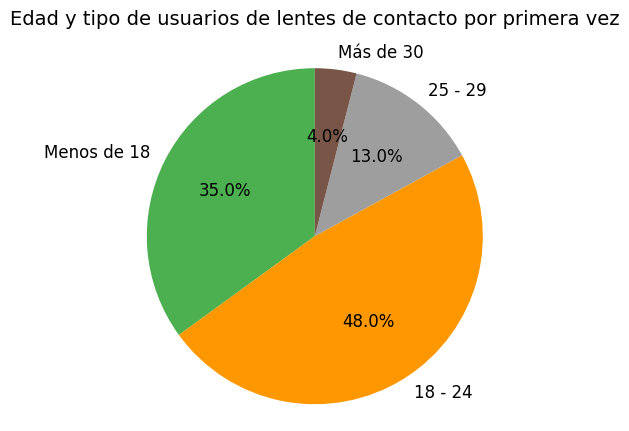

In [1]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np

# Datos
etiquetas = ['Menos de 18', '18 - 24', '25 - 29', 'Más de 30']
tamaños = [35, 48, 13, 4]
# Configuración de colores, lo más cercano posible al gráfico original
colores = ['#4CAF50', '#FF9800', '#9E9E9E', '#795548']  

# Crear un gráfico de pastel
fig, ax = plt.subplots()
porciones, textos, textos_automaticos = ax.pie(tamaños, labels=etiquetas, autopct='%1.1f%%',
                                  startangle=90, colors=colores)

# Establecer el tamaño de fuente y otros estilos para que la visualización sea más cercana al gráfico original
for texto in textos + textos_automaticos:
    texto.set_fontsize(12)

# El siguiente es el proceso general para agregar una imagen en el centro. Reemplace 'tu_ruta_de_imagen.png' con la ruta real de la imagen.
# Suponga que la imagen es cuadrada y ha sido procesada. Este es solo un ejemplo. Es posible que deba ajustar el tamaño, la posición, etc. en la práctica.
# imagen = plt.imread('tu_ruta_de_imagen.png')
# caja_imagen = OffsetImage(imagen, zoom=0.3)  # zoom ajusta el tamaño de la imagen
# ab = AnnotationBbox(caja_imagen, (0, 0), frameon=False)
# ax.add_artist(ab)

# Establecer el título del gráfico
ax.set_title('Edad y tipo de usuarios de lentes de contacto por primera vez', fontsize=14, y=1.05)

# Mantener el gráfico de pastel circular
ax.axis('equal')

plt.show()

# 文件: chart_38_2.py

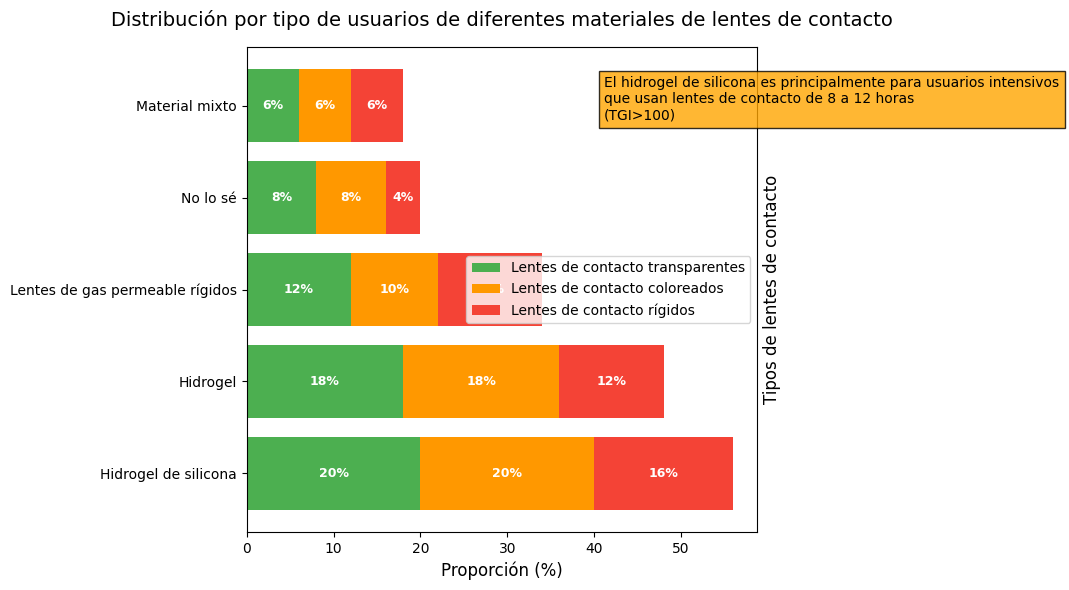

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres de las categorías
categorias = ["Hidrogel de silicona", "Hidrogel", "Lentes de gas permeable rígidos", "Material mixto", "No lo sé"]
# Datos de proporción de cada categoría correspondientes a diferentes tipos de lentes de contacto
datos = np.array([
    [20, 20, 16],
    [18, 18, 12],
    [12, 10, 12],
    [6, 6, 6],
    [8, 8, 4]
])

# Calcular el valor total de cada categoría
valores_totales = datos.sum(axis=1)

# Ordenar según el valor total (en orden descendente)
indices_ordenados = np.argsort(valores_totales)[::-1]

# Reordenar categorías y datos
categorias = [categorias[i] for i in indices_ordenados]
datos = datos[indices_ordenados]

# Transponer los datos para que cada columna corresponda a un tipo de lente de contacto
datos = datos.T

# Etiquetas y colores correspondientes para diferentes tipos de lentes de contacto
etiquetas = ["Lentes de contacto transparentes", "Lentes de contacto coloreados", "Lentes de contacto rígidos"]
colores = ["#4CAF50", "#FF9800", "#F44336"]  

# Crear un gráfico
fig, ax = plt.subplots(figsize=(10, 6))  # Aumentar el ancho adecuadamente para acomodar las etiquetas

# Dibujar un gráfico de barras apiladas
parte_inferior = np.zeros(len(categorias))
for i in range(len(etiquetas)):
    barras = ax.barh(categorias, datos[i], left=parte_inferior, color=colores[i], label=etiquetas[i])
    
    # Agregar etiquetas de datos a cada barra
    for barra, valor in zip(barras, datos[i]):
        if valor > 0:  # Mostrar solo valores no nulos
            ax.text(
                barra.get_x() + barra.get_width()/2,  # Posición x: centro de la barra
                barra.get_y() + barra.get_height()/2, # Posición y: centro de la barra
                f"{valor}%",                      # Mostrar el valor y el signo de porcentaje
                ha='center', va='center',         # Centrado horizontal y verticalmente
                color='white', fontweight='bold', # Texto blanco, en negrita
                fontsize=9                        # Tamaño de fuente
            )
    
    parte_inferior += datos[i]

# Agregar texto de anotación (ajustar la posición para evitar cubrir las etiquetas)
texto_anotacion = "El hidrogel de silicona es principalmente para usuarios intensivos\nque usan lentes de contacto de 8 a 12 horas\n(TGI>100)"
ax.text(0.7, 0.85, texto_anotacion, transform=ax.transAxes,
        bbox=dict(facecolor='orange', alpha=0.8), fontsize=10)

# Establecer atributos del gráfico
ax.yaxis.set_label_position("right")
ax.set_ylabel("Tipos de lentes de contacto", fontsize=12)
ax.set_xlabel("Proporción (%)", fontsize=12)
ax.set_title("Distribución por tipo de usuarios de diferentes materiales de lentes de contacto", fontsize=14, pad=15)
ax.legend(loc='center right')  # Ajustar la posición de la leyenda
plt.tight_layout()
plt.show()

# 文件: chart_38_3.py

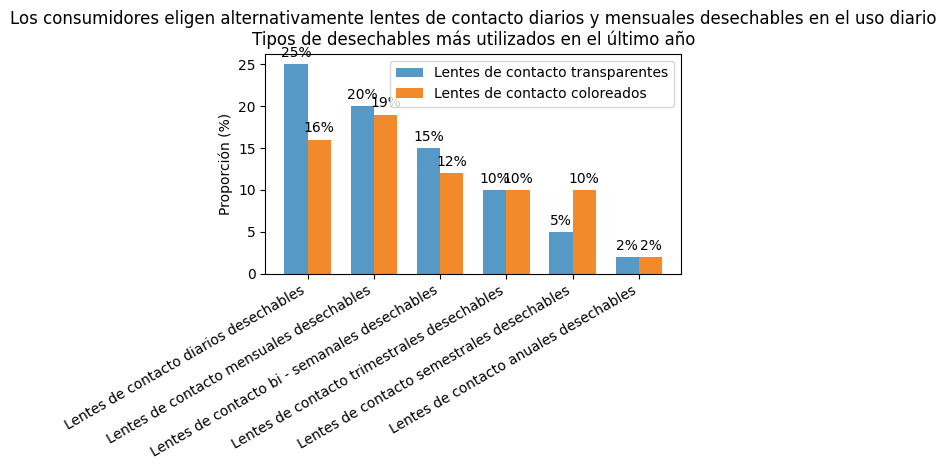

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Tipos de lentes de contacto desechables
categorias = ['Lentes de contacto diarios desechables', 'Lentes de contacto mensuales desechables', 'Lentes de contacto bi - semanales desechables', 'Lentes de contacto trimestrales desechables', 'Lentes de contacto semestrales desechables', 'Lentes de contacto anuales desechables']
# Proporción de lentes de contacto transparentes (datos simulados, generalmente cercanos a la proporción del ejemplo)
transparentes = [25, 20, 15, 10, 5, 2]
# Proporción de lentes de contacto coloreados (datos simulados, la suma es aproximadamente la proporción correspondiente en el ejemplo, como la suma de los diarios desechables es aproximadamente 41%)
coloridos = [16, 19, 12, 10, 10, 2]

x = np.arange(len(categorias))  # Posiciones en el eje x
ancho = 0.35  # Ancho de cada barra en el grupo

fig, ax = plt.subplots()
# Dibujar barras para lentes de contacto transparentes
rects1 = ax.bar(x - ancho/2, transparentes, ancho, label='Lentes de contacto transparentes', color='#5799C6')
# Dibujar barras para lentes de contacto coloreados
rects2 = ax.bar(x + ancho/2, coloridos, ancho, label='Lentes de contacto coloreados', color='#F28A2B')

# Establecer las marcas y etiquetas del eje x
ax.set_xticks(x)
ax.set_xticklabels(categorias, rotation=30, ha='right')
# Establecer la etiqueta del eje y
ax.set_ylabel('Proporción (%)')
# Establecer el título
ax.set_title('Los consumidores eligen alternativamente lentes de contacto diarios y mensuales desechables en el uso diario\nTipos de desechables más utilizados en el último año')
ax.legend()

# Anotar los valores encima de cada barra
def autolabel(rects):
    for rect in rects:
        altura = rect.get_height()
        ax.annotate('{}%'.format(altura),
                    xy=(rect.get_x() + rect.get_width() / 2, altura),
                    xytext=(0, 3),  # Desplazamiento vertical de la anotación numérica en relación a la barra
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

# 文件: chart_38_4.py

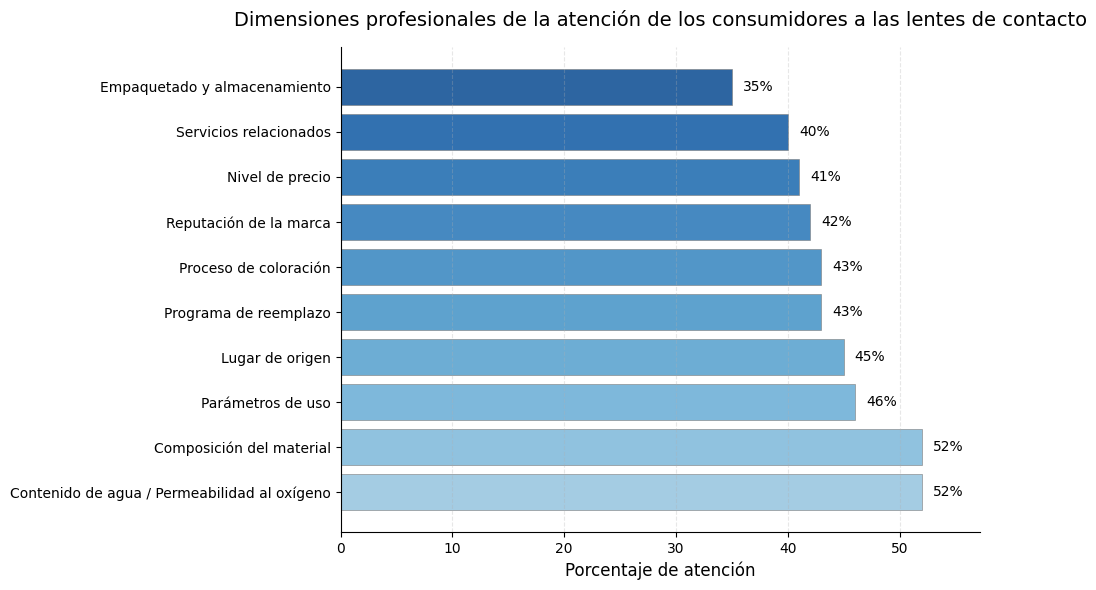

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
etiquetas = ['Contenido de agua / Permeabilidad al oxígeno', 'Composición del material', 'Parámetros de uso', 'Lugar de origen', 'Programa de reemplazo', 'Proceso de coloración', 'Reputación de la marca', 'Nivel de precio', 'Servicios relacionados', 'Empaquetado y almacenamiento']
valores = [52, 52, 46, 45, 43, 43, 42, 41, 40, 35]

# Definir posiciones en el eje y
pos_y = np.arange(len(etiquetas))

# Esquema de colores de gradiente optimizado (de azul oscuro a azul claro)
colores = plt.cm.Blues(np.linspace(0.4, 0.9, len(etiquetas)))

# Crear una figura (aumentar el tamaño)
fig, ax = plt.subplots(figsize=(10, 6))

# Dibujar un gráfico de barras horizontales (aumentar márgenes y transparencia)
barras = ax.barh(pos_y, valores, color=colores, alpha=0.85, edgecolor='gray', linewidth=0.5)

# Establecer etiquetas en el eje y (aumentar el espaciado de las etiquetas)
ax.set_yticks(pos_y)
ax.set_yticklabels(etiquetas, fontsize=10)

# Establecer etiqueta del eje x y título
ax.set_xlabel('Porcentaje de atención', fontsize=12)
ax.set_title('Dimensiones profesionales de la atención de los consumidores a las lentes de contacto', fontsize=14, pad=15)

# Optimizar las etiquetas numéricas (aumentar el tamaño de fuente y el color)
for i, v in enumerate(valores):
    ax.text(v + 1, i, f'{v}%', va='center', fontsize=10, color='black')

# Agregar líneas de cuadrícula (cuadrícula más clara)
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Establecer el rango del eje x (aumentar márgenes)
ax.set_xlim(0, max(valores) * 1.1)

# Embelezar el borde (ocultar los bordes superior y derecho)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()